# Residual autocorrelation

In this Python notebook we simulate data for an OLS model with some residual autocorrelation and study how to handle coefficients' standard errors

The model takes the form:

$$
Y_t = \beta_0 + \beta_1 X_t + u_t
$$

The residual is such that:

$$
\text{corr}(u_t, u_{t-h}) \neq 0 \; \text{for some} \; h
$$

## 0. Import requires packages

In [2]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf

## 1. Simulate data

We simulate data for $Y_t$, $X_t$ and $u_t$. The process governing $u_t$ is an autoregressive process of the form:

$$
u_t = \rho u_{t-1} + \epsilon_t
$$

where $\rho>0$ and $\epsilon_t$ is a random normal shock

In [3]:
np.random.seed(42)

# Simulate data
n = 200
x = np.random.normal(size=n)

# Autocorrelated errors: AR(1)
rho = 0.8
u = np.zeros(n)
eps = np.random.normal(size=n)

for t in range(1, n):
    u[t] = rho * u[t-1] + eps[t]

# Outcome
y = 1 + 2 * x + u

## 2. Estimate the model

The model is estimated using OLS. The standard errors are not corrected for heteroskedasticity and autocorrelation

In [4]:
# OLS
X = sm.add_constant(x)
ols = sm.OLS(y, X).fit()

print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.607
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     305.2
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           5.72e-42
Time:                        10:38:59   Log-Likelihood:                -371.28
No. Observations:                 200   AIC:                             746.6
Df Residuals:                     198   BIC:                             753.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3916      0.110     12.631      0.0

## 3. Investigate residual autocorrelation

To investigate wheter the model's residual suffer from autocorrelation we use the `acf` function from `statsmodels` and plot the residuals autocorelation at different lags. In other words we compute:

$$
\text{corr}(u_t, u_{t-h}), \quad \text{for} \; h=\{0, ..., H\}
$$

In [13]:
# Autocorrelation plot of residuals
# compute ACF values
acf_vals = acf(ols.resid, nlags=15)

lags = np.arange(len(acf_vals))

conf = 1.96 / np.sqrt(len(ols.resid))

## 4. Plot

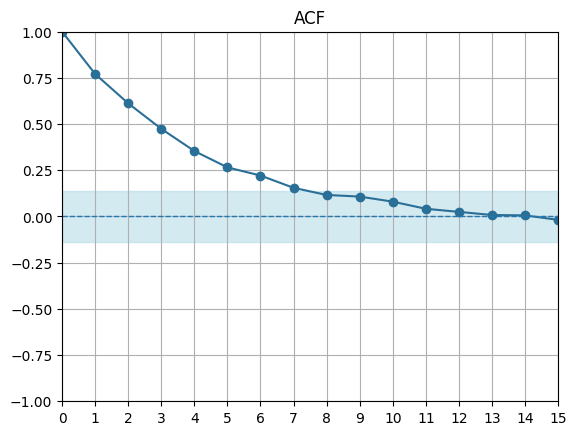

In [14]:
plt.figure()
plt.fill_between(lags, -conf, conf, color="#a9d6e5", alpha=0.5)
plt.plot(lags, acf_vals, marker='o', color="#2a6f97")
plt.axhline(0, linestyle='--', linewidth=1)
plt.xlim(0, 15)
plt.ylim(-1, 1)
plt.xticks(range(16))
plt.grid(True)
plt.title("ACF")
plt.show()

## 5. Correct for autocorrelation

We can correct the standard errors by applying the `get_robustcov_results` to the estimated model. The coefficients remain unchanged, but standard errors (and related statistics) adjust to the new covariance matrix.

In [15]:
# Same coefficients, HAC / Newey-West standard errors
hac = ols.get_robustcov_results(cov_type="HAC", maxlags=6)

print(hac.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.607
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     224.7
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           1.92e-34
Time:                        10:43:14   Log-Likelihood:                -371.28
No. Observations:                 200   AIC:                             746.6
Df Residuals:                     198   BIC:                             753.2
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3916      0.226      6.163      0.0